# Этап 4: Безопасная аугментация ИК-термограмм сотовых панелей

**Цель:** Увеличить объем обучающей выборки без искажения физического смысла данных. 
Поскольку объектом контроля является сотовая панель из стеклопластика с гексагональными ячейками, стандартные аугментации (произвольные повороты, перспективные искажения) неприменимы. Разработанный пайплайн включает геометрические, радиометрические и временные преобразования, адаптированные под физику активного теплового контроля с использованием нагревателя 500 Вт и тепловизора Optris PI 450.

In [3]:
import os
import sys
from pathlib import Path
import importlib

# Настройка путей для импорта кастомных скриптов
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# Загрузка всех разработанных аугментаторов
import scripts.augmentations
importlib.reload(scripts.augmentations)
from scripts.augmentations import (
    HoneycombSpatialAugmenter, 
    HoneycombTemporalAugmenter, 
    HoneycombRadiometricAugmenter,
    AdvancedHoneycombAugmenter
)

# Настройки графиков
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

In [4]:
# Вспомогательные функции
def to_u8(frame):
    low, high = np.nanpercentile(frame, [5, 95])
    norm = np.clip((frame - low) / max(high - low, 1e-6), 0, 1)
    return (norm * 255).astype(np.uint8)

def crop(img, bbox):
    x1, y1, x2, y2 = bbox
    if img.ndim == 3:
        return img[y1: y2 + 1, x1: x2 + 1, :]
    return img[y1: y2 + 1, x1: x2 + 1]

# Загрузка данных (в соответствии с каталогом проекта)
mat_path = Path(project_root) / "data" / "raw" / "сегмент 1 10гц 5с нагрев.mat"
#cp ~/projects/studcamp/data/water/water1.mat data/raw/сегмент 1 10гц 5с нагрев.mat
if mat_path.exists():
    mat = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    thermal_data = np.asarray(mat["data"], dtype=np.float32)
    print(f"Данные загружены. Размерность: {thermal_data.shape}")
else:
    print(f"Ошибка: Файл не найден по пути {mat_path.resolve()}")

# Координаты одной из 5 дефектных зон (72 ячейки)
fig1_sl = [210, 70, 295, 155]
patch_3d = crop(thermal_data, fig1_sl)

Данные загружены. Размерность: (480, 640, 3000)


### 1. Пространственная аугментация (Spatial)
Гексагональная структура сот обладает поворотной симметрией 6-го порядка. Безопасными преобразованиями являются отражения и повороты, кратные 60°. Для заполнения краев используется метод отражения (`BORDER_REFLECT`), исключающий появление черных рамок, которые нейросеть может ошибочно принять за границы дефектной зоны.

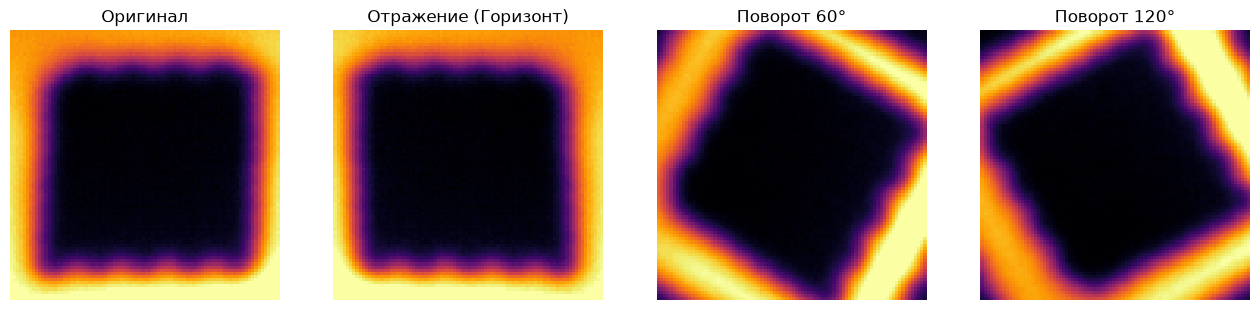

In [5]:
frame_idx = 100
patch_2d = patch_3d[:, :, frame_idx]

patch_flipped = HoneycombSpatialAugmenter.flip(patch_2d, axis='horizontal')
patch_rot60 = HoneycombSpatialAugmenter.rotate_hex(patch_2d, angle=60)
patch_rot120 = HoneycombSpatialAugmenter.rotate_hex(patch_2d, angle=120)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Оригинал', 'Отражение (Горизонт)', 'Поворот 60°', 'Поворот 120°']
for ax, p, title in zip(axs, [patch_2d, patch_flipped, patch_rot60, patch_rot120], titles):
    ax.imshow(to_u8(p), cmap='inferno') 
    ax.set_title(title)
    ax.axis('off')
plt.show()

**Вывод по пространственной аугментации:** 
Геометрия стенок сохранена идеально. Артефакты на границах отсутствуют, что позволяет использовать эти патчи для обучения моделей детекции (U-Net) и классификации 5-слойным перцептроном.

---
### 2. Радиометрическая и временная аугментации
Для повышения робастности классификатора добавляются искажения, имитирующие:
1. **Шум сенсора:** Тепловизионный модуль Optris PI 450 вносит собственные искажения.
2. **Вариацию нагрева:** Отклонения в мощности галогенного осветителя 500 Вт.
3. **Пропуски кадров:** Снижение частоты регистрации ниже заявленных 10 Гц.

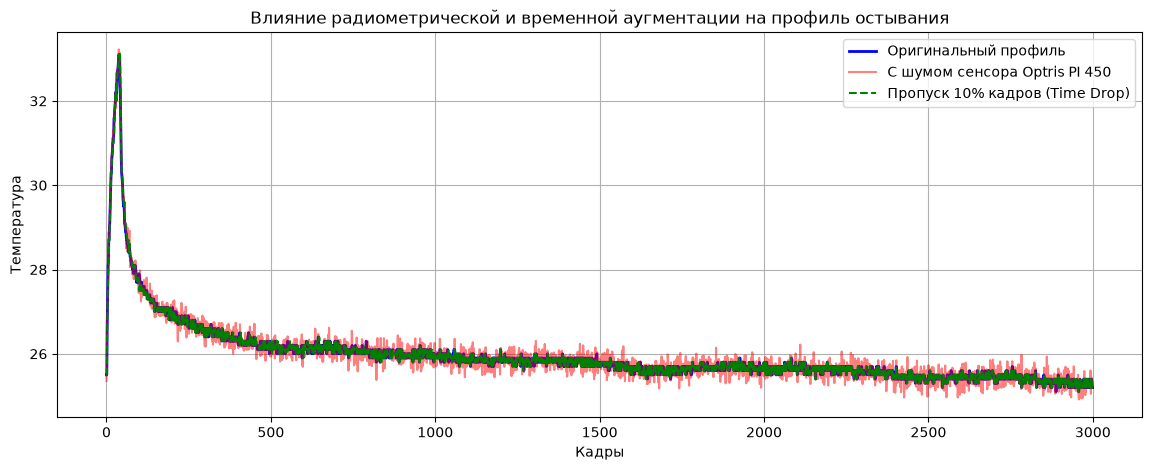

In [6]:
patch_time_dropped = HoneycombTemporalAugmenter.drop_frames(patch_3d, drop_fraction=0.1)
patch_noisy = HoneycombRadiometricAugmenter.add_sensor_noise(patch_3d, std=0.15)

center_y, center_x = patch_3d.shape[0] // 2, patch_3d.shape[1] // 2
profile_orig = patch_3d[center_y, center_x, :]
profile_dropped = patch_time_dropped[center_y, center_x, :]
profile_noisy = patch_noisy[center_y, center_x, :]

plt.figure(figsize=(14, 5))
plt.plot(profile_orig, label='Оригинальный профиль', color='blue', linewidth=2)
plt.plot(profile_noisy, label='С шумом сенсора Optris PI 450', color='red', alpha=0.5)

x_dropped = np.linspace(0, len(profile_orig), len(profile_dropped))
plt.plot(x_dropped, profile_dropped, label='Пропуск 10% кадров (Time Drop)', color='green', linestyle='dashed')

plt.title('Влияние радиометрической и временной аугментации на профиль остывания')
plt.xlabel('Кадры')
plt.ylabel('Температура')
plt.legend()
plt.show()

**Вывод по радиометрической и временной аугментации:** 
Зашумление температурного вектора не меняет его общей термодинамической логики, но предотвращает переобучение 5-слойной MLP-сети на идеальных лабораторных данных. Выпадение кадров подтверждает сохранение формы кривой при изменении FPS.

---
### 3. Продвинутые методы: Tile Dropout и MixUp
Эти методы решают специфические проблемы:
* **Tile Dropout:** Зануление участков внутри 72-ячеечной зоны заставляет сеть анализировать область целиком, а не "запоминать" один яркий пиксель.
* **MixUp:** Смешивание профилей позволяет генерировать промежуточные целевые значения (например, 50% заполнения на основе зон 40% и 60%), что служит фундаментом для Этапа 5 (Синтез данных).

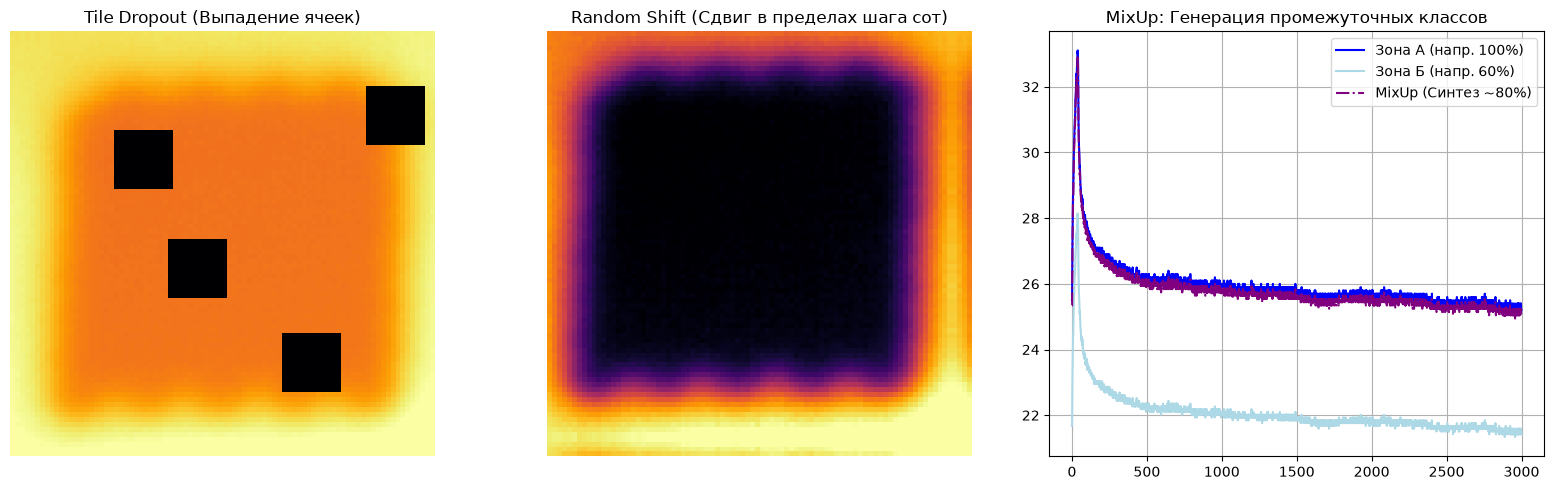

In [7]:
# Искусственный "холодный" патч для теста MixUp (в реальности - зона с другим % влаги)
patch_b_3d = patch_3d * 0.85 

patch_dropout = AdvancedHoneycombAugmenter.tile_dropout(patch_3d, tile_size=12, num_tiles=4)
patch_shifted = AdvancedHoneycombAugmenter.random_shift(patch_3d, max_shift=6)
patch_mixup = AdvancedHoneycombAugmenter.mixup(patch_3d, patch_b_3d, alpha=0.4)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# Отрисовка пространственных изменений
axs[0].imshow(to_u8(patch_dropout[:, :, frame_idx]), cmap='inferno')
axs[0].set_title('Tile Dropout (Выпадение ячеек)')
axs[0].axis('off')

axs[1].imshow(to_u8(patch_shifted[:, :, frame_idx]), cmap='inferno')
axs[1].set_title('Random Shift (Сдвиг в пределах шага сот)')
axs[1].axis('off')

# Отрисовка MixUp
profile_mixup = patch_mixup[center_y, center_x, :]
profile_b = patch_b_3d[center_y, center_x, :]

axs[2].plot(profile_orig, label='Зона А (напр. 100%)', color='blue')
axs[2].plot(profile_b, label='Зона Б (напр. 60%)', color='lightblue')
axs[2].plot(profile_mixup, label='MixUp (Синтез ~80%)', color='purple', linestyle='-.')
axs[2].set_title('MixUp: Генерация промежуточных классов')
axs[2].legend()

plt.tight_layout()
plt.show()